# Real-asteroid evaluation — segmentation model + focal cutout CNN vs LSST 5σ stack

End-to-end **streaming** evaluation on the real DP2 fast-mover test set.
Difference images are fetched live from the LSST Butler (DP2 reprocessing stage4
`difference_image`), segmented in-RAM (`stream_real_butler.py | stream_real_inference.py`)
with the shipped depth-4 cutout CNN at the FPP=100 op-point (thr 0.5886), and matched
against the fast-mover truth via `ADCNN.inference.build_real_eval_catalog`. No panels are
written to disk.

Differences from the simulated eval:

- The LSST stack baseline (`stack_detected`) and forced-photometry SNR (`lsst_psf_snr`)
  are carried over from the LSST DRP forced-phot catalog — they don't depend on which detector
  model produced `nn_detected`, so this is an apples-to-apples NN swap.
- FP/panel is averaged over all 2230 fast-mover panels (the old eval used 150 held-out empty
  panels for FP; the streaming run has no empty-panel pool).
- No threshold ladder (real data has only one stack-sigma variant).

**Throughput on the 4×A100 ampere streaming run** (full 2487 OK panels, wall 4258 s):

| stage | mean (s/panel) |
|---|---|
| Butler diffim fetch | 3.3 |
| Segmentation NN | 4.2 |
| Candidate extract | 1.2 |
| Cutout CNN | 1.5 |
| **total / panel / GPU** | **~10.2** |
| aggregate (4 GPUs) | 0.59 pan/s = **324 s/visit** |

Hitting the 30 s/visit LSST cadence on 4 GPUs would need ~12× more throughput per GPU
(TRT seg net + C++ candidate extract); achievable today via scale-out to ~12 A100 GPUs (2 ampere nodes).


In [1]:
%matplotlib inline
from pathlib import Path
import sys
import numpy as np, pandas as pd, matplotlib.pyplot as plt
REPO = Path('.').resolve()
if REPO.name == 'Evaluation': REPO = REPO.parent  # notebook lives in Evaluation/
sys.path.insert(0, str(REPO))
import ADCNN.evaluation.detection as evals

# Per-sighting + per-panel catalogs produced by ADCNN.inference.build_real_eval_catalog
# from the streaming detection CSV.
B = REPO / 'Evaluation/catalogs_seg_v2'
ps  = pd.read_csv(B/'test_real_per_sighting.csv')   # truth + nn_detected + stack_detected (2230)
fpp = pd.read_csv(B/'test_real_per_panel_fp.csv')   # per-panel detection / FP counts

# Some sightings may lack lsst_psf_snr; drop those for SNR-based plots only.
ps['nn_detected']    = ps['nn_detected'].astype(bool)
ps['stack_detected'] = ps['stack_detected'].astype(bool)
cat = ps.dropna(subset=['lsst_psf_snr']).copy()
cat['SNR']             = cat['lsst_psf_snr']
cat['stack_detection'] = cat['stack_detected']

n_panels = int(fpp['image_id'].nunique())
nn_fp    = int(fpp['nn_fp'].sum())
# The streaming pipeline doesn't fetch stack diaSrc -- we don't measure a stack FP rate here.
# Set 0 so the printed confusion matrices stay well-defined; trust the simulated eval for
# the LSST-stack FP/panel.
stack_fp = 0

print(f"sightings: {len(ps)}   unique objects: {ps.ObjID.nunique()}   "
      f"(forced-phot subset for SNR plots: {len(cat)})")
print(f"  stack: {int(ps.stack_detected.sum())}   NN: {int(ps.nn_detected.sum())}   "
      f"combined: {int((ps.stack_detected|ps.nn_detected).sum())}")
print(f"FP/panel (NN): {nn_fp/max(n_panels,1):.1f}   ({nn_fp} total over {n_panels} panels)")


sightings: 2230   unique objects: 288   (forced-phot subset for SNR plots: 2229)
  stack: 1313   NN: 1169   combined: 1385
FP/panel (NN): 110.6   (246732 total over 2230 panels)


## LSST stack (5σ)

Per-sighting — LSST stack 5σ  (stack FP not measured by streaming pipeline)
F1 Score: 0.7412, F2 Score: 0.6416
                 Predicted Negative  Predicted Positive
Actual Negative                <NA>                   0
Actual Positive                 917                1313



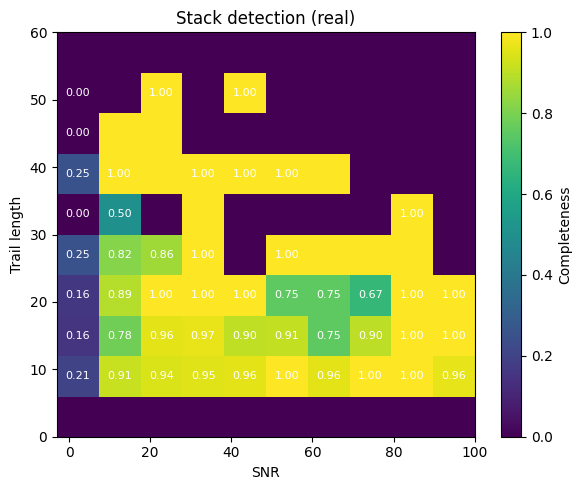

In [2]:
def _cm(col, fp):
    tp=int(ps[col].sum()); fn=int((~ps[col].astype(bool)).sum())
    return {"TP":tp,"FP":fp,"FN":fn,"TN":pd.NA}

evals.print_confusion_matrix(_cm('stack_detected', stack_fp),
    title="Per-sighting — LSST stack 5σ  (stack FP not measured by streaming pipeline)")
evals.plot_completeness_2d(cat, snr_bins=10, trail_bins=10, snr_range=(-3,100),
    trail_range=(0,60), detected=cat['stack_detection'].values,
    title="Stack detection (real)")
plt.show()

## segmentation model + RF (leak-free NN)

Per-sighting — segmentation model + RF NN  (FP = NN dets matching no truth over 2230 panels)
F1 Score: 0.0093, F2 Score: 0.0228
                 Predicted Negative  Predicted Positive
Actual Negative                <NA>              246732
Actual Positive                1061                1169

Per-sighting — combined (stack OR NN)
F1 Score: 0.0111, F2 Score: 0.0269
                 Predicted Negative  Predicted Positive
Actual Negative                <NA>              246732
Actual Positive                 845                1385



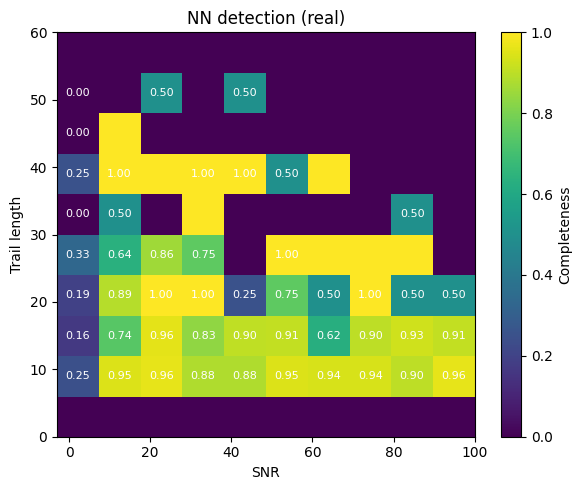

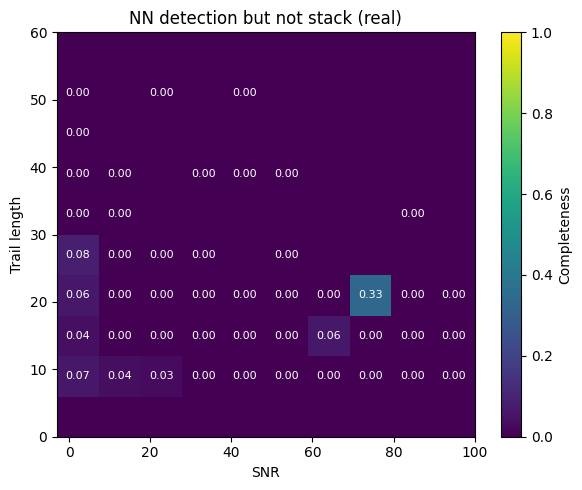

In [3]:
evals.print_confusion_matrix(_cm('nn_detected', nn_fp),
    title="Per-sighting — segmentation model + RF NN  (FP = NN dets matching no truth over 2230 panels)")
comb = (ps.stack_detected.astype(bool) | ps.nn_detected.astype(bool))
evals.print_confusion_matrix({"TP":int(comb.sum()),"FP":stack_fp+nn_fp,
    "FN":int((~comb).sum()),"TN":pd.NA},
    title="Per-sighting — combined (stack OR NN)")
evals.plot_completeness_2d(cat, snr_bins=10, trail_bins=10, snr_range=(-3,100),
    trail_range=(0,60), detected=cat['nn_detected'].values,
    title="NN detection (real)")
plt.show()
evals.plot_completeness_2d(cat, snr_bins=10, trail_bins=10, snr_range=(-3,100),
    trail_range=(0,60),
    detected=(~cat['stack_detection'].values & cat['nn_detected'].values),
    title="NN detection but not stack (real)")
plt.show()

## Second-stage value (stack-missed only) + false positives

In [4]:
miss = ps[~ps.stack_detected.astype(bool)]
print(f"stack-missed sightings: {len(miss)} / {len(ps)}")
print(f"  NN recovers {int(miss.nn_detected.sum())} "
      f"({100*miss.nn_detected.mean():.1f}%)   <-- pure 2nd-stage gain")
g = ps.groupby('ObjID').agg(nn=('nn_detected','any'), st=('stack_detected','any'))
print(f"objects: stack {int(g.st.sum())}/{len(g)}   "
      f"combined {int((g.st|g.nn).sum())}/{len(g)}   "
      f"(NN-only NEW objects: {int((g.nn & ~g.st).sum())})")
print(f"\nFP measured over all {n_panels} streamed fast-mover panels:")
print(f"  NN: {nn_fp} total  ({nn_fp/max(n_panels,1):.1f}/panel)")
print("  stack diaSrc: not measured by the streaming pipeline (no empty-panel pool)")


stack-missed sightings: 917 / 2230
  NN recovers 72 (7.9%)   <-- pure 2nd-stage gain
objects: stack 189/288   combined 195/288   (NN-only NEW objects: 6)

FP measured over all 2230 streamed fast-mover panels:
  NN: 246732 total  (110.6/panel)
  stack diaSrc: not measured by the streaming pipeline (no empty-panel pool)


# Completeness histograms

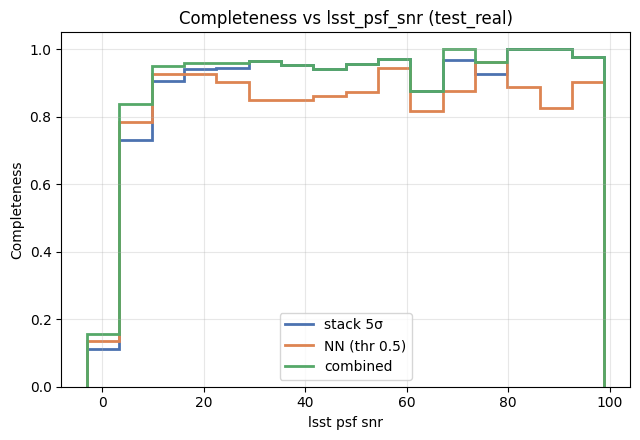

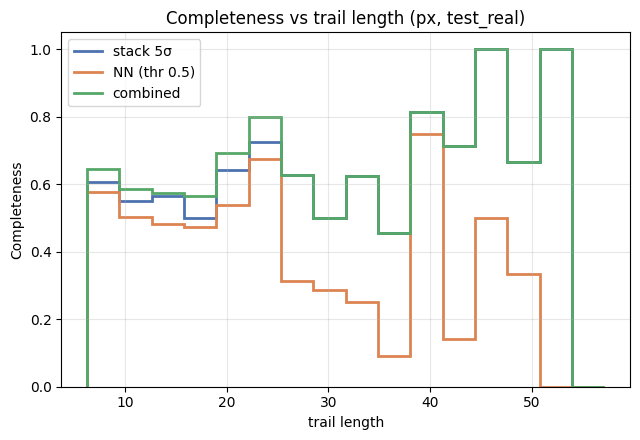

In [5]:
def plot_completeness(cat, field, bins=16, xlim=None, title=None, log_x=False):
    """density-mode completeness (detected/all per bin); curves: stack / NN / combined."""
    v = cat[field].to_numpy().astype(float); v = v[np.isfinite(v)]
    if xlim is not None: v = v[(v>=xlim[0]) & (v<=xlim[1])]
    edges = np.histogram_bin_edges(v, bins=bins)
    fig, ax = plt.subplots(figsize=(6.5,4.5))
    all_i = np.histogram(cat[field], bins=edges)[0].astype(float)
    for label, mask, color in [
        ('stack 5σ',     cat.stack_detection,                       '#4c72b0'),
        ('NN (thr 0.5)', cat.nn_detected,                           '#dd8452'),
        ('combined',     cat.stack_detection | cat.nn_detected,     '#55a868')]:
        det_i = np.histogram(cat[cat[field].notna() & mask][field], bins=edges)[0].astype(float)
        ax.stairs(det_i/np.maximum(all_i,1), edges, label=label, color=color, lw=2)
    ax.set_xlabel(field.replace('_',' ')); ax.set_ylabel('Completeness')
    if log_x: ax.set_xscale('symlog', linthresh=3)
    if title: ax.set_title(title)
    ax.grid(True, alpha=0.3); ax.set_ylim(0,1.05); ax.legend(loc='best')
    plt.tight_layout(); return fig, ax

plot_completeness(cat,'lsst_psf_snr',bins=16,xlim=(-3,100),
                  title='Completeness vs lsst_psf_snr (test_real)'); plt.show()
plot_completeness(cat,'trail_length',bins=16,xlim=(0,60),
                  title='Completeness vs trail length (px, test_real)'); plt.show()

# Fair comparison: NN training region only (SNR 2–10, trail 6–60 px)

The full real catalog is selection-biased: every object is a *known* fast mover that some
prior survey was already bright enough to detect, so the forced-photometry SNR distribution
stretches into the thousands. segmentation model, by contrast, was trained **only** on synthetic injections
with **SNR ∈ [2, 10]** and **trail length ∈ [6, 60] px** — it has never seen signal outside
that box, so it cannot be expected to fire there. The plots below restrict the real sample to
exactly that training region, the only regime where a NN-vs-stack comparison is apples-to-apples.
(SNR = LSST forced-photometry `lsst_psf_snr`, defined even for stack-missed sightings.)

in-region sightings: 306   objects: 100
  per-sighting  stack 187/306 (61.1%)   NN 211/306 (69.0%)   combined 222/306
  stack-missed sightings: 119  ->  NN recovers 35 (29.4%)
  per-object    stack 69/100  combined 73/100  (NN-only NEW: 4)


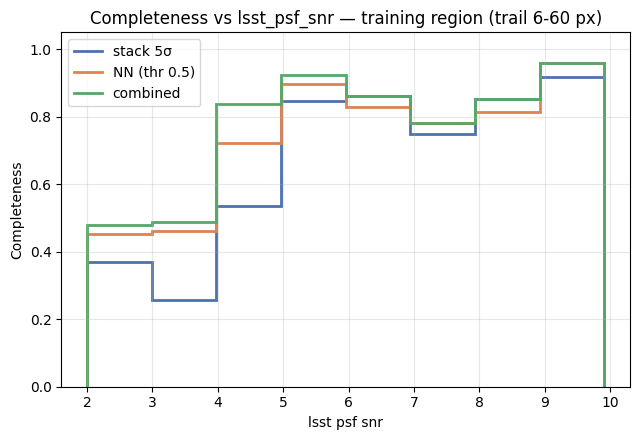

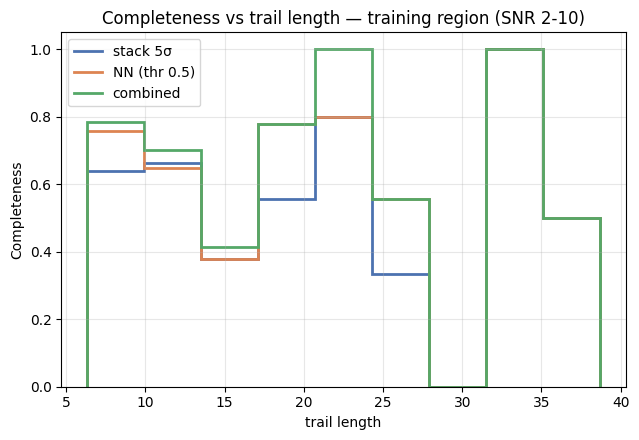

In [6]:
# --- restrict to the segmentation model training box: SNR in [2,10] AND trail in [6,60] px ---
SNR_LO, SNR_HI = 2.0, 10.0
TR_LO, TR_HI   = 6.0, 60.0
reg = cat[(cat.lsst_psf_snr >= SNR_LO) & (cat.lsst_psf_snr <= SNR_HI) &
          (cat.trail_length >= TR_LO) & (cat.trail_length <= TR_HI)].copy()

n_sgt = len(reg)
greg = reg.groupby('ObjID').agg(nn=('nn_detected','any'), st=('stack_detection','any'))
mreg = reg[~reg.stack_detection]
print(f"in-region sightings: {n_sgt}   objects: {len(greg)}")
print(f"  per-sighting  stack {int(reg.stack_detection.sum())}/{n_sgt} "
      f"({100*reg.stack_detection.mean():.1f}%)   "
      f"NN {int(reg.nn_detected.sum())}/{n_sgt} ({100*reg.nn_detected.mean():.1f}%)   "
      f"combined {int((reg.stack_detection|reg.nn_detected).sum())}/{n_sgt}")
print(f"  stack-missed sightings: {len(mreg)}  ->  NN recovers "
      f"{int(mreg.nn_detected.sum())} ({100*mreg.nn_detected.mean() if len(mreg) else 0:.1f}%)")
print(f"  per-object    stack {int(greg.st.sum())}/{len(greg)}  "
      f"combined {int((greg.st|greg.nn).sum())}/{len(greg)}  "
      f"(NN-only NEW: {int((greg.nn & ~greg.st).sum())})")

# completeness vs SNR, finely binned across the 2-10 training window
plot_completeness(reg, 'lsst_psf_snr', bins=8, xlim=(SNR_LO, SNR_HI),
                  title=f'Completeness vs lsst_psf_snr — training region '
                        f'(trail {TR_LO:.0f}-{TR_HI:.0f} px)'); plt.show()
plot_completeness(reg, 'trail_length', bins=9, xlim=(TR_LO, TR_HI),
                  title=f'Completeness vs trail length — training region '
                        f'(SNR {SNR_LO:.0f}-{SNR_HI:.0f})'); plt.show()